In [17]:
# DIKRA ARDAHI 


===== Régression logistique =====
theta0 (bias) = -5.383500032040243
theta1 (weight) = 0.2770469475859296
Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]


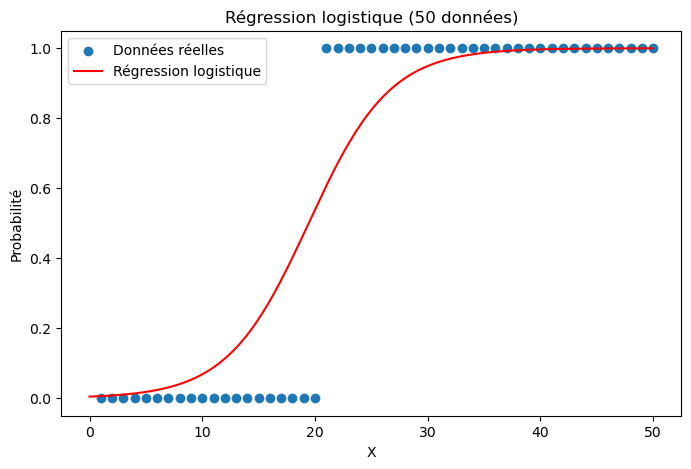

In [18]:
# ce code montre l'utilisation de la régression logistique from scratch 

# ============================================
# 1. IMPORTATION DES BIBLIOTHÈQUES
# ============================================

import numpy as np
# numpy: bibliothèque pour manipuler les vecteurs et matrices (calcul scientifique)

import matplotlib.pyplot as plt
# matplotlib: bibliothèque pour tracer des graphiques


# ============================================
# 2. DONNÉES
# ============================================


# Dataset simple pour classification binaire
# X = score (0 à 50)
# y = 0 (échec), 1 (réussite)
# objectif : apprendre une frontière de décision

X = np.array([
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
    21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
    31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
    41, 42, 43, 44, 45, 46, 47, 48, 49, 50
])
# X: variable explicative (input)
# 50 observations numériques
# chaque valeur représente un exemple

y = np.array([
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,
    0,0,0,0,0,
    1,1,1,1,1,
    1,1,1,1,1,
    1,1,1,1,1,
    1,1,1,1,1,
    1,1,1,1,1,
    1,1,1,1,1
])
# y: variable cible (output)
# 0 = échec
# 1 = réussite
# problème de classification binaire


# ============================================
# 3. FONCTION SIGMOID
# ============================================

def sigmoid(z):
    # z: combinaison linéaire des variables (X * theta)
    # transforme une valeur en probabilité entre 0 et 1
    return 1 / (1 + np.exp(-z))
    # exp = fonction exponentielle


# ============================================
# 4. AJOUT DU BIAS
# ============================================

X = X.reshape(-1, 1)
# reshape: transforme X en matrice colonne (50,1)

X_b = np.c_[np.ones((len(X), 1)), X]
# np.ones((len(X),1)) -> colonne de 1 (bias)
# np.c_ -> concatène colonnes
# résultat:
# [1  X]
# [1  X]
# ceci permet d'ajouter theta0 (intercept)


# ============================================
# 5. INITIALISATION
# ============================================

theta = np.zeros(X_b.shape[1])
# theta = paramètres du modèle
# shape[1] = nombre de colonnes (bias + feature)
# ici: theta = [theta0, theta1]

alpha = 0.05
# alpha = learning rate (vitesse d'apprentissage)
# petit => stable
# grand => rapide mais instable

iterations = 2000
# nombre d'itérations du gradient descent


# ============================================
# 6. GRADIENT DESCENT
# ============================================

for i in range(iterations):
    # boucle d'apprentissage

    z = X_b.dot(theta)
    # z = X * theta (produit matriciel)
    # combinaison linéaire

    h = sigmoid(z)
    # h = probabilité prédite par le modèle

    
    error = h - y
    # erreur entre prédiction et réalité

    gradient = (1/len(y)) * X_b.T.dot(error)
    # gradient = direction de correction
    # X_b.T = transpose de la matrice

    theta = theta - alpha * gradient
    # mise à jour des paramètres
    # correction progressive du modèle


# ============================================
# 7. RÉSULTATS
# ============================================

print("===== Régression logistique =====")

print("theta0 (bias) =", theta[0])
# theta0 = intercept (biais)

print("theta1 (weight) =", theta[1])
# theta1 = poids de la variable X


# ============================================
# 8. PRÉDICTION
# ============================================

def predict(X_new):
    # X_new: nouvelles données

    X_new = X_new.reshape(-1, 1)
    # transformation en matrice colonne

    X_new_b = np.c_[np.ones((len(X_new), 1)), X_new]
    # ajout du bias

    prob = sigmoid(X_new_b.dot(theta))
    # calcul des probabilités

    return (prob >= 0.5).astype(int)
    # seuil 0.5:
    # >= 0.5 => classe 1
    # < 0.5  => classe 0


print("Predictions:", predict(X))
# test du modèle sur les données existantes


# ============================================
# 9. VISUALISATION
# ============================================

X_curve = np.linspace(0, 50, 200).reshape(-1, 1)
# création de points pour tracer une courbe lisse

X_curve_b = np.c_[np.ones((len(X_curve), 1)), X_curve]
# ajout du bias

y_curve = sigmoid(X_curve_b.dot(theta))
# calcul de la courbe sigmoid

plt.figure(figsize=(8,5))
# taille du graphique

plt.scatter(X, y, label="Données réelles")
# affichage des points réels

plt.plot(X_curve, y_curve, color="red", label="Régression logistique")
# courbe sigmoid du modèle

plt.title("Régression logistique (50 données)")
plt.xlabel("X")
plt.ylabel("Probabilité")
plt.legend()

plt.show()
# affichage final du graphique